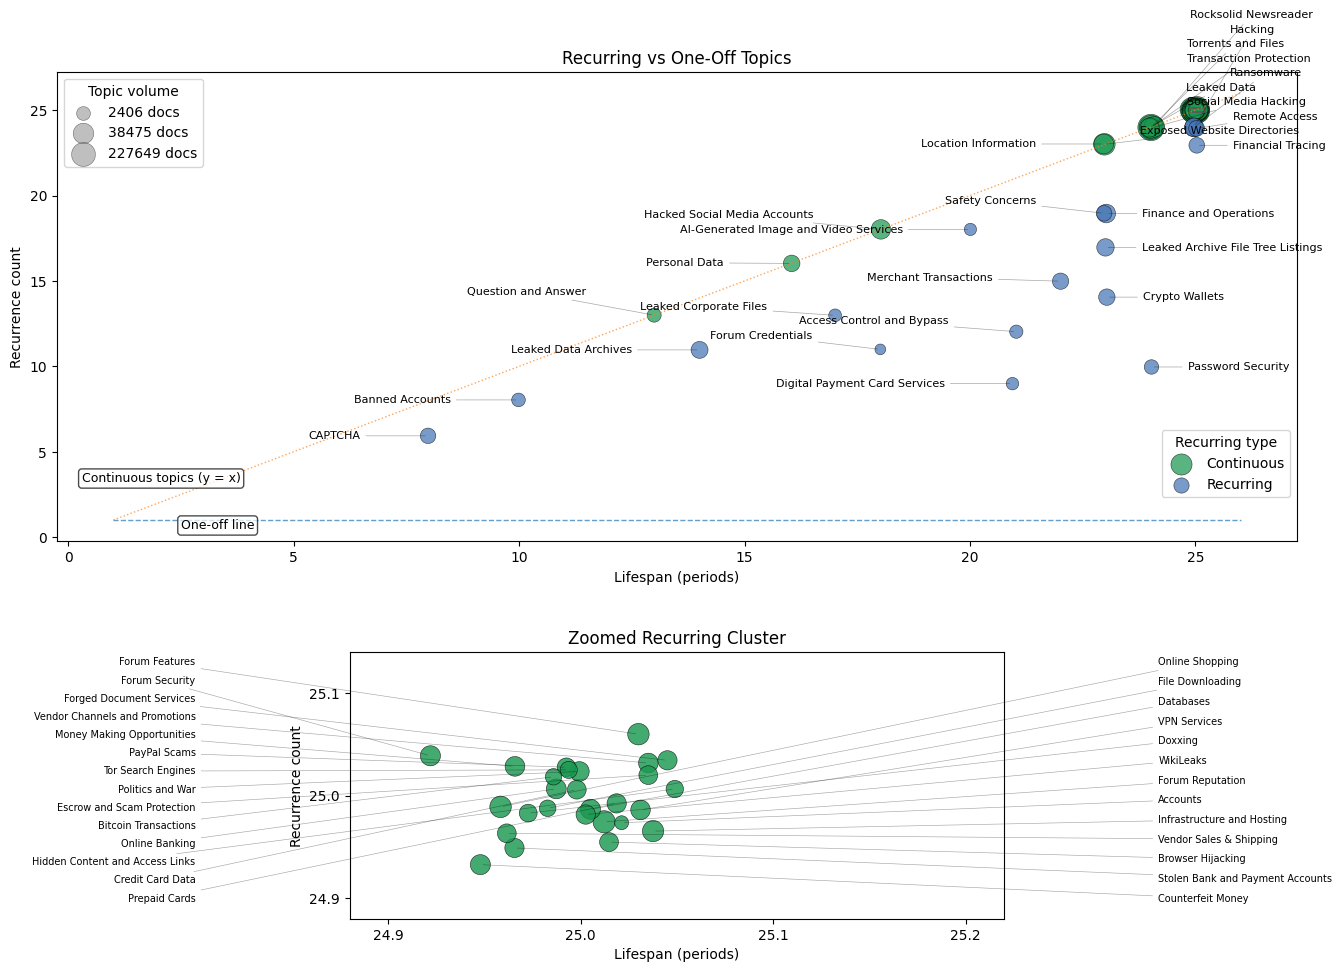

Saved recurrence figure PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2c/recurring_vs_oneoff_two_panel_clean_v2.pdf
Saved recurrence figure PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2c/recurring_vs_oneoff_two_panel_clean_v2.png
Saved recurrence features to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2c/recurring_vs_oneoff_topic_features_two_panel_clean_v2.csv
Saved recurrence summary to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2c/recurring_vs_oneoff_summary_two_panel_clean_v2.csv

Recurring type summary:


,Recurring_Type,Topics,Mean_Lifespan,Mean_Recurrence,Mean_Gaps
0,Continuous,37,24.000000,24.000000,0.0
1,Recurring,18,20.388889,15.388889,5.0



Top recurrence features:


,Final,Lifespan_Periods,Recurrence_Count,Gap_Count,Recurring_Type,Total_Count
0,Forum Reputation,25,25,0,Continuous,903883
1,Online Shopping,25,25,0,Continuous,558270
2,Forum Features,25,25,0,Continuous,524089
3,Infrastructure and Hosting,25,25,0,Continuous,461151
4,Forum Security,25,25,0,Continuous,204509
5,Counterfeit Money,25,25,0,Continuous,197892
6,Databases,25,25,0,Continuous,192833
7,Online Banking,25,25,0,Continuous,175989
8,Politics and War,25,25,0,Continuous,159594
9,Money Making Opportunities,25,25,0,Continuous,156609


In [18]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_DIR = Path("./rq2c")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PDF = OUT_DIR / "recurring_vs_oneoff_two_panel_clean_v2.pdf"
FIG_PNG = OUT_DIR / "recurring_vs_oneoff_two_panel_clean_v2.png"

OUT_FEATURES = OUT_DIR / "recurring_vs_oneoff_topic_features_two_panel_clean_v2.csv"
OUT_SUMMARY = OUT_DIR / "recurring_vs_oneoff_summary_two_panel_clean_v2.csv"

# -------------------------
# SETTINGS
# -------------------------
PERIOD_MODE = "Q"
DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"

BUBBLE_MIN = 60
BUBBLE_MAX = 360
MAX_LABEL_LEN = 90

# cluster region
ZOOM_X_MIN = 24.88
ZOOM_X_MAX = 25.22
ZOOM_Y_MIN = 24.88
ZOOM_Y_MAX = 25.14

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

RECURRING_COLORS = {
    "One-Off": "#d73027",
    "Continuous": "#1a9850",
    "Recurring": "#4575b4",
}

# -------------------------
# HELPERS
# -------------------------
def detect_delimiter(path: Path):
    with open(path, "r", encoding="utf-8-sig") as f:
        line = f.readline()
    return ";" if line.count(";") > line.count(",") else ","


def load_grouped_labels(path: Path):
    rows = []
    delim = detect_delimiter(path)
    with open(path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=delim)
        for r in reader:
            tids = (r.get("Topic_ID") or "").split(",")
            final_label = (r.get("Final") or "").strip()
            for t in tids:
                t = t.strip()
                if t.isdigit():
                    rows.append({"Topic": int(t), "Final": final_label})

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed from final_labeling.csv")
    return df


def load_filtered_metadata_from_jsonl(path: Path, primary_field: str, fallback_field: str):
    rows = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            text = rec.get(primary_field, "")
            if not (isinstance(text, str) and text.strip()):
                text = rec.get(fallback_field, "")
                if not (isinstance(text, str) and text.strip()):
                    continue

            rows.append({"created_at": rec.get("created_at")})
    return pd.DataFrame(rows)


def build_period_column(dt_series, mode="Q"):
    if mode == "M":
        return dt_series.dt.to_period("M").astype(str)
    elif mode == "Q":
        return dt_series.dt.to_period("Q").astype(str)
    elif mode == "4M":
        years = dt_series.dt.year
        months = dt_series.dt.month
        bin_start = (((months - 1) // 4) * 4) + 1
        return years.astype(str) + "-" + bin_start.astype(str).str.zfill(2)
    raise ValueError("PERIOD_MODE must be one of: 'M', 'Q', '4M'")


def shorten(label, max_len=90):
    label = str(label)
    return label if len(label) <= max_len else label[:max_len - 3] + "..."


def place_noncluster_labels(ax, df, x_col, y_col, text_col, fontsize=8):
    """
    Label only non-cluster points on the overview chart.
    """
    if df.empty:
        return

    x_mid = df[x_col].median()
    left = df[df[x_col] <= x_mid].sort_values(y_col).copy()
    right = df[df[x_col] > x_mid].sort_values(y_col).copy()

    prev_y = None
    for _, row in left.iterrows():
        x = float(row[x_col])
        y = float(row[y_col])
        ly = y if prev_y is None else max(y, prev_y + 0.85)
        prev_y = ly
        ax.annotate(
            str(row[text_col]),
            (x, y),
            xytext=(x - 1.5, ly),
            textcoords="data",
            ha="right",
            va="center",
            fontsize=fontsize,
            arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.35)
        )

    prev_y = None
    for _, row in right.iterrows():
        x = float(row[x_col])
        y = float(row[y_col])
        ly = y if prev_y is None else max(y, prev_y + 0.85)
        prev_y = ly
        ax.annotate(
            str(row[text_col]),
            (x, y),
            xytext=(x + 0.8, ly),
            textcoords="data",
            ha="left",
            va="center",
            fontsize=fontsize,
            arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.35)
        )


def place_zoom_labels_two_sides(ax, df, x_col, y_col, text_col, fontsize=7):
    """
    Put zoom-panel labels in left and right outer columns.
    """
    if df.empty:
        return

    df = df.sort_values([y_col, x_col], ascending=[False, True]).copy().reset_index(drop=True)
    x_left, x_right = ax.get_xlim()
    y_bottom, y_top = ax.get_ylim()

    n = len(df)
    left_n = int(np.ceil(n / 2))
    right_n = n - left_n

    left_df = df.iloc[:left_n].copy()
    right_df = df.iloc[left_n:].copy()

    left_ys = np.linspace(y_top - 0.01, y_bottom + 0.02, left_n) if left_n else []
    right_ys = np.linspace(y_top - 0.01, y_bottom + 0.02, right_n) if right_n else []

    x_label_left = x_left - 0.08
    x_label_right = x_right + 0.08

    for (_, row), ly in zip(left_df.iterrows(), left_ys):
        x = float(row[x_col])
        y = float(row[y_col])
        ax.annotate(
            str(row[text_col]),
            (x, y),
            xytext=(x_label_left, ly),
            textcoords="data",
            ha="right",
            va="center",
            fontsize=fontsize,
            arrowprops=dict(arrowstyle="-", lw=0.45, alpha=0.35),
            clip_on=False
        )

    for (_, row), ly in zip(right_df.iterrows(), right_ys):
        x = float(row[x_col])
        y = float(row[y_col])
        ax.annotate(
            str(row[text_col]),
            (x, y),
            xytext=(x_label_right, ly),
            textcoords="data",
            ha="left",
            va="center",
            fontsize=fontsize,
            arrowprops=dict(arrowstyle="-", lw=0.45, alpha=0.35),
            clip_on=False
        )

# -------------------------
# LOAD DATA
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_

meta_df = load_filtered_metadata_from_jsonl(
    JSONL_PATH,
    primary_field=DOC_FIELD_PRIMARY,
    fallback_field=DOC_FIELD_FALLBACK
)

labels_df = load_grouped_labels(LABELS_PATH)

if len(meta_df) != len(topics):
    raise ValueError(
        f"Mismatch after training-style filtering: {len(meta_df):,} filtered rows vs {len(topics):,} topic assignments."
    )

meta_df = meta_df.copy()
meta_df["Topic"] = topics
meta_df = meta_df[(meta_df["Topic"] != -1) & meta_df["created_at"].notna()].copy()

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()].copy()
meta_df["Period"] = build_period_column(meta_df["datetime"], PERIOD_MODE)

df = meta_df.merge(labels_df, on="Topic", how="left")
df["Final"] = df["Final"].fillna("Unlabeled")

# -------------------------
# PERIOD x TOPIC COUNTS
# -------------------------
long_df = (
    df.groupby(["Period", "Final"], as_index=False)
      .size()
      .rename(columns={"size": "Count"})
)

wide_counts = long_df.pivot(index="Final", columns="Period", values="Count").fillna(0)

# -------------------------
# RECURRENCE FEATURES
# -------------------------
rows = []
for topic in wide_counts.index:
    counts = wide_counts.loc[topic].values
    active = (counts > 0).astype(int)
    active_idx = np.where(active == 1)[0]

    if len(active_idx) == 0:
        continue

    first_idx = int(active_idx[0])
    last_idx = int(active_idx[-1])
    lifespan_periods = last_idx - first_idx + 1
    recurrence_count = int(active.sum())
    gap_count = int(np.sum(active[first_idx:last_idx + 1] == 0))

    if recurrence_count == 1:
        recurring_type = "One-Off"
    elif gap_count == 0:
        recurring_type = "Continuous"
    else:
        recurring_type = "Recurring"

    rows.append({
        "Final": topic,
        "Lifespan_Periods": lifespan_periods,
        "Recurrence_Count": recurrence_count,
        "Gap_Count": gap_count,
        "Recurring_Type": recurring_type,
        "Total_Count": int(counts.sum()),
    })

features_df = pd.DataFrame(rows).sort_values(
    ["Recurring_Type", "Recurrence_Count", "Total_Count"],
    ascending=[True, False, False]
).reset_index(drop=True)

features_df.to_csv(OUT_FEATURES, sep=";", index=False, encoding="utf-8-sig")

summary_df = (
    features_df.groupby("Recurring_Type", as_index=False)
    .agg(
        Topics=("Final", "count"),
        Mean_Lifespan=("Lifespan_Periods", "mean"),
        Mean_Recurrence=("Recurrence_Count", "mean"),
        Mean_Gaps=("Gap_Count", "mean"),
    )
)
summary_df.to_csv(OUT_SUMMARY, sep=";", index=False, encoding="utf-8-sig")

# -------------------------
# PREPARE PLOT DATA
# -------------------------
plot_df = features_df.copy()
vol = np.log10(plot_df["Total_Count"].clip(lower=1))
plot_df["bubble_size"] = np.interp(
    vol,
    (vol.min(), vol.max()),
    (BUBBLE_MIN, BUBBLE_MAX)
)

rng = np.random.default_rng(42)
plot_df["x_j"] = plot_df["Lifespan_Periods"] + rng.normal(0, 0.04, size=len(plot_df))
plot_df["y_j"] = plot_df["Recurrence_Count"] + rng.normal(0, 0.04, size=len(plot_df))

zoom_mask = (
    (plot_df["x_j"] >= ZOOM_X_MIN) & (plot_df["x_j"] <= ZOOM_X_MAX) &
    (plot_df["y_j"] >= ZOOM_Y_MIN) & (plot_df["y_j"] <= ZOOM_Y_MAX)
)
zoom_df = plot_df[zoom_mask].copy()
non_zoom_df = plot_df[~zoom_mask].copy()

# -------------------------
# LAYOUT: FULL-WIDTH TOP, NARROWER CENTERED BOTTOM
# -------------------------
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[2.2, 1.25],
    width_ratios=[1.0, 2.4, 1.0],
    hspace=0.30,
    wspace=0.05
)

ax1 = fig.add_subplot(gs[0, :])   # full width top
ax2 = fig.add_subplot(gs[1, 1])   # only middle column on bottom

# ===== Top: overview =====
for rtype, sub in plot_df.groupby("Recurring_Type"):
    ax1.scatter(
        sub["x_j"],
        sub["y_j"],
        s=sub["bubble_size"],
        alpha=0.72,
        label=rtype,
        color=RECURRING_COLORS.get(rtype, None),
        edgecolors="black",
        linewidths=0.4
    )

xmax = max(plot_df["Lifespan_Periods"].max(), plot_df["Recurrence_Count"].max()) + 1
ax1.plot([1, xmax], [1, 1], linestyle="--", linewidth=1.0, alpha=0.7)
ax1.plot([1, xmax], [1, xmax], linestyle=":", linewidth=1.0, alpha=0.7)

# moved to bottom-left
ax1.text(
    0.02, 0.12,
    "Continuous topics (y = x)",
    ha="left",
    va="bottom",
    transform=ax1.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.7)
)

ax1.text(
    0.10, 0.02,
    "One-off line",
    ha="left",
    va="bottom",
    transform=ax1.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.7)
)

# IMPORTANT: no cluster labels on main chart
non_zoom_df["Label"] = non_zoom_df["Final"].apply(lambda x: shorten(x, MAX_LABEL_LEN))
place_noncluster_labels(
    ax1,
    non_zoom_df.sort_values(["Total_Count", "Recurrence_Count"], ascending=[False, False]),
    x_col="x_j",
    y_col="y_j",
    text_col="Label",
    fontsize=8
)

# zoom rectangle
rect = plt.Rectangle(
    (ZOOM_X_MIN, ZOOM_Y_MIN),
    ZOOM_X_MAX - ZOOM_X_MIN,
    ZOOM_Y_MAX - ZOOM_Y_MIN,
    fill=False, edgecolor="0.35", linewidth=1.2
)
ax1.add_patch(rect)

ax1.set_xlabel("Lifespan (periods)")
ax1.set_ylabel("Recurrence count")
ax1.set_title("Recurring vs One-Off Topics")

legend1 = ax1.legend(title="Recurring type", loc="lower right", bbox_to_anchor=(1.0, 0.08))
ax1.add_artist(legend1)

sample_vals = np.quantile(plot_df["Total_Count"], [0.1, 0.5, 0.9]).astype(int)
handles = []
labels = []
for val in sample_vals:
    s = np.interp(
        np.log10(max(val, 1)),
        (vol.min(), vol.max()),
        (BUBBLE_MIN, BUBBLE_MAX)
    )
    handles.append(ax1.scatter([], [], s=s, color="gray", alpha=0.5, edgecolors="black", linewidths=0.4))
    labels.append(f"{val} docs")
ax1.legend(handles, labels, title="Topic volume", loc="upper left")

# ===== Bottom: narrower centered zoom panel =====
for rtype, sub in zoom_df.groupby("Recurring_Type"):
    ax2.scatter(
        sub["x_j"],
        sub["y_j"],
        s=sub["bubble_size"] * 0.72,
        alpha=0.82,
        color=RECURRING_COLORS.get(rtype, None),
        edgecolors="black",
        linewidths=0.4
    )

ax2.set_xlim(ZOOM_X_MIN, ZOOM_X_MAX)
ax2.set_ylim(ZOOM_Y_MIN, ZOOM_Y_MAX)
ax2.set_xticks([24.9, 25.0, 25.1, 25.2])
ax2.set_yticks([24.9, 25.0, 25.1])
ax2.set_xlabel("Lifespan (periods)")
ax2.set_ylabel("Recurrence count")
ax2.set_title("Zoomed Recurring Cluster")

zoom_df["Label"] = zoom_df["Final"]
place_zoom_labels_two_sides(
    ax2,
    zoom_df.sort_values(["Total_Count", "Recurrence_Count"], ascending=[False, False]),
    x_col="x_j",
    y_col="y_j",
    text_col="Label",
    fontsize=7
)

plt.tight_layout()
plt.savefig(FIG_PDF, bbox_inches="tight")
plt.savefig(FIG_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved recurrence figure PDF to: {FIG_PDF.resolve()}")
print(f"Saved recurrence figure PNG to: {FIG_PNG.resolve()}")
print(f"Saved recurrence features to: {OUT_FEATURES.resolve()}")
print(f"Saved recurrence summary to: {OUT_SUMMARY.resolve()}")

print("\nRecurring type summary:")
display(summary_df)

print("\nTop recurrence features:")
display(features_df.head(20))